# About

This jupyter notebook is (one of) the first steps in the pipeline for the human_microbiome_compendium analysis.

Below contains the pipeline for loading the raw data, doing the appropriate filtering, and outputting the dataset files necessary for training & invoking the downstream models.

The dataset name is `american_gut_USCA`.

In [1]:
import os
from pathlib import Path
import pandas as pd
import matplotlib.pyplot as plt

from common.preprocess import *

In [2]:
""" cache directory. """
NOTEBOOK_CACHE = Path("/data/bwh-comppath-seq/youn/human_microbiome_compendium") / "american_gut_USCA"
NOTEBOOK_CACHE.mkdir(exist_ok=True, parents=True)

""" Huggingface token """
with open("hf_token.txt", "rt") as f:
    token = f.readline().strip()
    assert len(token) > 0, "File 'hf_token.txt' should contain the hugging face token in the first line."
    os.environ["HF_TOKEN"] = token
    print("Successfully set huggingface token from file 'hf_token.txt'!")

Successfully set huggingface token from file 'hf_token.txt'!


# Dataset Files

File locations and metadata.

In [3]:
data_base_dir = Path("/data/cctm/youn/human_microbiome_compendium")

project_metadata_file = data_base_dir / "projects.csv"
asv_sequence_file = data_base_dir / "obs_md.txt.zst"  # tsv format: ASV_NAME    ASV_SEQ, has a header.
abundance_table_dir = data_base_dir / "asv"
sample_metadata_file = data_base_dir / "sample_metadata.tsv"

assert asv_sequence_file.exists(), f"Expected {asv_sequence_file} to exist."
assert asv_sequence_file.is_file(), f"Expected {asv_sequence_file} to be a file."
assert abundance_table_dir.exists(), f"Expected {asv_sequence_file} to exist."
assert abundance_table_dir.is_dir(), f"Expected {abundance_table_dir} to be a directory."
assert sample_metadata_file.exists(), f"Expected {sample_metadata_file} to exist."
assert sample_metadata_file.is_file(), f"Expected {sample_metadata_file} to be a file."

""" Load the project metadata as a pandas dataframe. """
project_metadata = pd.read_csv(project_metadata_file, sep=',')
print("# projects:", project_metadata.shape[0])

""" Load the sample metadata as a pandas dataframe. """
sample_metadata = pd.read_csv(sample_metadata_file, sep='\t')
print("# samples:", sample_metadata.shape[0])

# projects: 482
# samples: 168464


# Projects -- Target Subset by ID

In [4]:
PROJECT_IDS = ["PRJEB11419"]
for project_id in PROJECT_IDS:
    print_project_info(project_id, sample_metadata)

Project: PRJEB11419
	regions: ['unknown' 'Europe and Northern America'
 'Northern Africa and Western Asia' 'Australia/New Zealand'
 'Eastern and South-Eastern Asia' 'Sub-Saharan Africa'
 'Latin America and the Caribbean' 'Central and Southern Asia' 'Oceania']
	isos: ['unknown' 'GB' 'US' 'FR' 'IS' 'AT' 'SE' 'CA' 'CH' 'AM' 'NZ' 'GR' 'NO'
 'MY' 'NL' 'HU' 'KE' 'CO' 'IL' 'BD' 'ES' 'DK' 'BE' 'IE' 'DE' 'AU' 'ZW'
 'FI' 'IT' 'IN' 'UM' 'AE' 'UG' 'PT' 'HR' 'LT' 'TR' 'PL' 'BR' 'SG' 'PE']
	num samples: 4850


# Sample & project filtering.

In [5]:
project_subset = project_metadata.loc[
    (project_metadata['condition'] == 'healthy')
    & (project_metadata['amplicon'] == 'v4')
    & project_metadata['project'].isin(PROJECT_IDS),
    :
]

sample_subset = sample_metadata.loc[
    sample_metadata['iso'].isin({"US", "CA"})  # filter by region.
    & sample_metadata['project'].isin(set(project_subset['project']))  # filter by results of "project_subset".
    & (sample_metadata['instrument'] == 'Illumina MiSeq')  # filter by sequencing instrument.
]
print("[*] Stage 1 filter: {} samples remaining".format(sample_subset.shape[0]))

[*] Stage 1 filter: 1463 samples remaining


In [6]:
project_subset, sample_subset, asv_seqs_subset, sample_max_num_asvs = filter_samples_and_asvs(
    project_subset, sample_subset,
    target_project_ids=set(PROJECT_IDS),
    abundance_table_dir=abundance_table_dir,
    asv_sequence_file=asv_sequence_file,
)

[Project PRJEB11419] Read count statistics:
         read_counts
count    1463.000000
mean    26387.110731
std     14416.527274
min         1.000000
25%     18309.000000
50%     23894.000000
75%     32628.000000
max    362398.000000
[Project PRJEB11419] Using read count threshold of 9620.400000000001 < x < 51783.150000000016
*********************************
[*] Stage 2 filter: 1389 samples remaining
                count
project    iso       
PRJEB11419 US    1267
           CA     122
[* Pre-ASV selection filtering] PROJECT PRJEB11419: 1389 samples, 24528 ASVs
Filtering ASVs by (# samples with count >= 10) >= 1
[* Post-ASV selection filtering] PROJECT PRJEB11419: 1307 samples, 7167 ASVs
This project contributes 7167 new ASVs after filtering.
Num. project-relevant ASVs: 7167
Per-sample max num. ASV: 331


# Process 16S sequences.

Keep only sequences that are actually 16S. (some are 18s by accident!)

In [7]:
ASV_SEQ_PROCESSING_DIR = NOTEBOOK_CACHE / "asv_16s_processing"
ASV_SEQ_PROCESSING_DIR.mkdir(exist_ok=True, parents=True)

"""
Note: defer_to_hpc option makes this pipeline print HPC instructions and raise an error.
Follow the directions, and re-run this cell.
"""
asv_seqs_subset = pipeline_16s_validation(
    asv_seqs_subset,
    cache_dir=ASV_SEQ_PROCESSING_DIR,
    silva_db=data_base_dir / "silva_nr99_v138.2_train_set.fa.gz",
    vsearch_path='vsearch',
    vsearch_num_threads=12,
    min_identity=0.95,
)
# asv_seqs_subset = pipeline_16s_validation(
#     asv_seqs_subset,
#     cache_dir=ASV_SEQ_PROCESSING_DIR,
#     blast_db=Path("/data/cctm/blast_dbs/core_nt/core_nt"),
#     defer_to_hpc=True
# )

Wrote 7167 sequences to /data/bwh-comppath-seq/youn/human_microbiome_compendium/american_gut_USCA/asv_16s_processing/asv_sequences.fasta
VSEARCH found: vsearch v2.30.4_linux_x86_64, 62.5GB RAM, 32 cores
Found 7167 sequences in input file.
Using database: /data/cctm/youn/human_microbiome_compendium/silva_nr99_v138.2_train_set.fa.gz
Minimum identity threshold: 95.0%
Strategy: Keeping only bacterial sequences, filtering out Archaea and Eukaryota

Running VSEARCH on /data/bwh-comppath-seq/youn/human_microbiome_compendium/american_gut_USCA/asv_16s_processing/asv_sequences.fasta against /data/cctm/youn/human_microbiome_compendium/silva_nr99_v138.2_train_set.fa.gz...
Running command: vsearch --usearch_global /data/bwh-comppath-seq/youn/human_microbiome_compendium/american_gut_USCA/asv_16s_processing/asv_sequences.fasta --db /data/cctm/youn/human_microbiome_compendium/silva_nr99_v138.2_train_set.fa.gz --id 0.95 --maxaccepts 5 --maxrejects 32 --threads 12 --blast6out /data/bwh-comppath-seq/youn

In [9]:
""" Run the alignment. """
asv_sequence_file_postblast = ASV_SEQ_PROCESSING_DIR / "asv_sequences.post_filter.fasta"
asv_align_file = ASV_SEQ_PROCESSING_DIR / "asv_alignment.fasta"

dict_to_fasta(asv_seqs_subset, asv_sequence_file_postblast)
run_mafft(asv_sequence_file_postblast, asv_align_file, 'mafft')

Wrote 6738 sequences to /data/bwh-comppath-seq/youn/human_microbiome_compendium/american_gut_USCA/asv_16s_processing/asv_sequences.post_filter.fasta
MAFFT alignment completed successfully: /data/bwh-comppath-seq/youn/human_microbiome_compendium/american_gut_USCA/asv_16s_processing/asv_alignment.fasta


Max ASV sequence length: 127


Text(0, 0.5, 'Count')

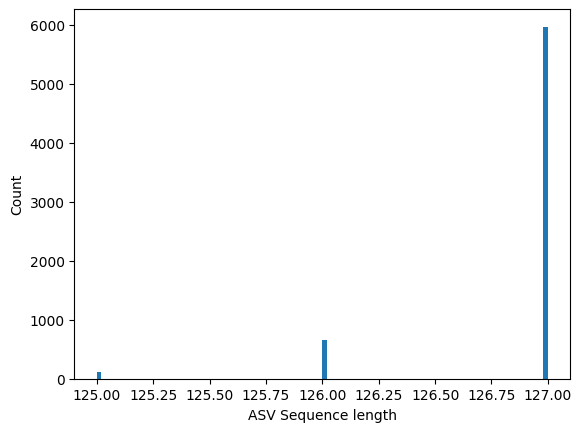

In [10]:
""" Compute the max sequence length. """
MAX_ASV_SEQUENCE_LEN = max(len(s) for s in asv_seqs_subset.values())
print("Max ASV sequence length:", MAX_ASV_SEQUENCE_LEN)

""" Plot ASV length frequency histogram """
fig, ax = plt.subplots(1, 1)
ax.hist([len(s) for s in asv_seqs_subset.values()], bins=100)
ax.set_xlabel("ASV Sequence length")
ax.set_ylabel("Count")

# Train-test split.

In [11]:
""" Option 1: Train: US, Test: CA """

train_df = sample_subset.loc[sample_subset['iso'] == 'US']
test_df = sample_subset.loc[sample_subset['iso'] == 'CA']
print("# train samples: {}".format(train_df.shape[0]))
print("# test samples: {}".format(test_df.shape[0]))

train_df.to_csv(NOTEBOOK_CACHE / "train.tsv", sep="\t", index=False)
test_df.to_csv(NOTEBOOK_CACHE / "test.tsv", sep="\t", index=False)

# train samples: 1189
# test samples: 118


In [12]:
train_df

,srs,project,srr,library_strategy,library_source,pubdate,total_bases,instrument,geo_loc_name,iso,region,read_counts
0,ERS5806610,PRJEB11419,ERR5337772,AMPLICON,METAGENOMIC,2021-03-16 23:07:16,5251385.0,Illumina MiSeq,usa:nc,US,Europe and Northern America,33678
1,ERS5806611,PRJEB11419,ERR5337773,AMPLICON,METAGENOMIC,2021-03-16 23:07:16,3821866.0,Illumina MiSeq,usa:unspecified,US,Europe and Northern America,24318
2,ERS5806637,PRJEB11419,ERR5337799,AMPLICON,METAGENOMIC,2021-03-16 23:07:16,4759715.0,Illumina MiSeq,usa:ca,US,Europe and Northern America,30227
3,ERS5806676,PRJEB11419,ERR5337838,AMPLICON,METAGENOMIC,2021-03-16 23:07:17,5165547.0,Illumina MiSeq,usa:unspecified,US,Europe and Northern America,32842
4,ERS5806745,PRJEB11419,ERR5337908,AMPLICON,METAGENOMIC,2021-03-16 23:07:18,5552606.0,Illumina MiSeq,usa:unspecified,US,Europe and Northern America,34997
...,...,...,...,...,...,...,...,...,...,...,...,...
1381,ERS5802277,PRJEB11419,ERR5332931,AMPLICON,METAGENOMIC,2021-03-16 21:58:12,2954206.0,Illumina MiSeq,usa:unspecified,US,Europe and Northern America,19027
1385,ERS5802295,PRJEB11419,ERR5332950,AMPLICON,METAGENOMIC,2021-03-16 21:58:12,5421370.0,Illumina MiSeq,usa:unspecified,US,Europe and Northern America,34725
1386,ERS5802298,PRJEB11419,ERR5332953,AMPLICON,METAGENOMIC,2021-03-16 21:58:12,4664316.0,Illumina MiSeq,usa:unspecified,US,Europe and Northern America,29159
1387,ERS5802300,PRJEB11419,ERR5332955,AMPLICON,METAGENOMIC,2021-03-16 21:58:12,2858890.0,Illumina MiSeq,usa:unspecified,US,Europe and Northern America,18203


In [13]:
project_subset

,project,link,amplicon,avg_length,bead_beating,kit,sample_type,condition,subjects,notes
41,PRJEB11419,https://doi.org/10.1128/mSystems.00031-18,v4,126.93,False,NaN,stool,healthy,adults,NaN
